In [1]:
import os
import pandas as pd

In [2]:
data_folder = "data"

files = [f for f in os.listdir(data_folder) if f.endswith(".csv")]
print("Files found:", files)

df_list = []

for file in files:
    temp = pd.read_csv(os.path.join(data_folder, file))
    temp["Season"] = file.replace(".csv", "")
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print("Shape:", df.shape)
df.head()

Files found: ['SP1 (1).csv', 'SP1 (2).csv', 'SP1 (3).csv', 'SP1 (4).csv', 'SP1 (5).csv', 'SP1 (6).csv', 'SP1 (7).csv', 'SP1 (8).csv', 'SP1 (9).csv', 'SP1.csv']


C:\Users\bains\AppData\Local\Temp\ipykernel_40060\409251733.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  temp["Season"] = file.replace(".csv", "")


Shape: (3700, 180)


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,BMGMCA,BVCH,BVCD,BVCA,CLCH,CLCD,CLCA,LBCH,LBCD,LBCA
0,SP1,15/08/2024,18:00,Ath Bilbao,Getafe,1,1,D,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SP1,15/08/2024,20:30,Betis,Girona,1,1,D,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SP1,16/08/2024,18:00,Celta,Alaves,2,1,H,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SP1,16/08/2024,20:30,Las Palmas,Sevilla,2,2,D,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SP1,17/08/2024,18:00,Osasuna,Leganes,1,1,D,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

CLCA    3482
LBCH    3482
LBCA    3482
LBCD    3482
CLCH    3482
        ... 
PSH       95
PSD       95
PSCD      93
PSCA      93
PSCH      93
Length: 154, dtype: int64


In [4]:
threshold = len(df) * 0.5
df_clean = df.dropna(axis=1, thresh=threshold)

print("Original shape:", df.shape)
print("After dropping sparse columns:", df_clean.shape)

Original shape: (3700, 180)
After dropping sparse columns: (3700, 103)


In [5]:
columns_to_keep = [
    'Date', 'HomeTeam', 'AwayTeam',
    'FTHG', 'FTAG', 'FTR',
    'HTHG', 'HTAG', 'HTR',
    'HS', 'AS', 'HST', 'AST',
    'HF', 'AF', 'HC', 'AC',
    'HY', 'AY', 'HR', 'AR',
    'Season'
]

df_clean = df_clean[columns_to_keep]
print(df_clean.shape)
df_clean.head()

(3700, 22)


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,...,AST,HF,AF,HC,AC,HY,AY,HR,AR,Season
0,15/08/2024,Ath Bilbao,Getafe,1,1,D,1,0,H,7,...,2,15,12,5,6,4,1,0,0,SP1 (1)
1,15/08/2024,Betis,Girona,1,1,D,1,0,H,19,...,2,11,7,4,4,2,0,0,0,SP1 (1)
2,16/08/2024,Celta,Alaves,2,1,H,0,1,A,6,...,2,8,23,3,3,3,2,0,0,SP1 (1)
3,16/08/2024,Las Palmas,Sevilla,2,2,D,1,1,D,13,...,5,12,13,6,3,0,0,0,0,SP1 (1)
4,17/08/2024,Osasuna,Leganes,1,1,D,0,1,A,16,...,4,14,12,6,4,3,2,0,0,SP1 (1)


In [6]:
raw_dates = df_clean['Date'].astype(str).str.strip()

date_long = pd.to_datetime(raw_dates, format='%d/%m/%Y', errors='coerce')
date_short = pd.to_datetime(raw_dates, format='%d/%m/%y', errors='coerce')

df_clean['Date'] = date_long.fillna(date_short)

print(df_clean[['Date']].head(10))
print("Missing dates:", df_clean['Date'].isnull().sum())

        Date
0 2024-08-15
1 2024-08-15
2 2024-08-16
3 2024-08-16
4 2024-08-17
5 2024-08-17
6 2024-08-18
7 2024-08-18
8 2024-08-19
9 2024-08-19
Missing dates: 0


In [7]:
df_clean = df_clean.dropna(subset=['Date'])
print("After dropping missing dates:", df_clean.shape) # drop rows where there is no Date

After dropping missing dates: (3700, 22)


In [8]:
df_clean = df_clean.sort_values('Date').reset_index(drop=True)
df_clean.head() # Sorting from oldest to newest (checking only first 5)

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,...,AST,HF,AF,HC,AC,HY,AY,HR,AR,Season
0,2015-08-21,Malaga,Sevilla,0,0,D,0,0,D,25,...,2,19,11,7,2,3,3,0,1,SP1 (9)
1,2015-08-22,La Coruna,Sociedad,0,0,D,0,0,D,15,...,2,16,10,5,4,3,2,0,0,SP1 (9)
2,2015-08-22,Ath Madrid,Las Palmas,1,0,H,1,0,H,14,...,1,11,16,4,4,2,0,0,0,SP1 (9)
3,2015-08-22,Espanol,Getafe,1,0,H,1,0,H,4,...,3,19,14,5,6,2,3,0,1,SP1 (9)
4,2015-08-22,Vallecano,Valencia,0,0,D,0,0,D,8,...,4,19,11,3,3,3,1,0,0,SP1 (9)


In [9]:
print(df_clean[['Date']].head(5))
print(df_clean[['Date']].tail(5)) #check if in order

        Date
0 2015-08-21
1 2015-08-22
2 2015-08-22
3 2015-08-22
4 2015-08-22
           Date
3695 2026-03-15
3696 2026-03-15
3697 2026-03-15
3698 2026-03-15
3699 2026-03-16


In [10]:
print(df_clean.isnull().sum()) #check to see if data is cleaned 

Date        0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
HTHG        0
HTAG        0
HTR         0
HS          0
AS          0
HST         0
AST         0
HF          0
AF          0
HC          0
AC          0
HY          0
AY          0
HR          0
AR          0
Season      0
dtype: int64


In [11]:
df_clean.head(50)

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,...,AST,HF,AF,HC,AC,HY,AY,HR,AR,Season
0,2015-08-21,Malaga,Sevilla,0,0,D,0,0,D,25,...,2,19,11,7,2,3,3,0,1,SP1 (9)
1,2015-08-22,La Coruna,Sociedad,0,0,D,0,0,D,15,...,2,16,10,5,4,3,2,0,0,SP1 (9)
2,2015-08-22,Ath Madrid,Las Palmas,1,0,H,1,0,H,14,...,1,11,16,4,4,2,0,0,0,SP1 (9)
3,2015-08-22,Espanol,Getafe,1,0,H,1,0,H,4,...,3,19,14,5,6,2,3,0,1,SP1 (9)
4,2015-08-22,Vallecano,Valencia,0,0,D,0,0,D,8,...,4,19,11,3,3,3,1,0,0,SP1 (9)
5,2015-08-23,Ath Bilbao,Barcelona,0,1,A,0,0,D,8,...,4,16,11,2,4,3,3,0,0,SP1 (9)
6,2015-08-23,Betis,Villarreal,1,1,D,0,1,A,22,...,4,11,26,7,5,3,1,0,1,SP1 (9)
7,2015-08-23,Levante,Celta,1,2,A,0,1,A,11,...,6,12,17,4,6,1,3,1,0,SP1 (9)
8,2015-08-23,Sp Gijon,Real Madrid,0,0,D,0,0,D,6,...,8,20,4,2,5,4,0,0,0,SP1 (9)
9,2015-08-24,Granada,Eibar,1,3,A,0,2,A,12,...,4,5,23,6,5,1,6,1,0,SP1 (9)


In [ ]:
#Supervised model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X = df_clean[['HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HY', 'AY']]
y = df_clean['FTR'].map({'H': 1, 'D': 0, 'A': -1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.6108108108108108
              precision    recall  f1-score   support

          -1       0.55      0.62      0.58       196
           0       0.45      0.19      0.26       192
           1       0.67      0.84      0.74       352

    accuracy                           0.61       740
   macro avg       0.56      0.55      0.53       740
weighted avg       0.58      0.61      0.58       740



In [14]:
print(df_clean.shape)
print(df_clean.columns)
df_clean.head()

(3700, 22)
Index(['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG',
       'HTR', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY',
       'HR', 'AR', 'Season'],
      dtype='str')


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,...,AST,HF,AF,HC,AC,HY,AY,HR,AR,Season
0,2015-08-21,Malaga,Sevilla,0,0,D,0,0,D,25,...,2,19,11,7,2,3,3,0,1,SP1 (9)
1,2015-08-22,La Coruna,Sociedad,0,0,D,0,0,D,15,...,2,16,10,5,4,3,2,0,0,SP1 (9)
2,2015-08-22,Ath Madrid,Las Palmas,1,0,H,1,0,H,14,...,1,11,16,4,4,2,0,0,0,SP1 (9)
3,2015-08-22,Espanol,Getafe,1,0,H,1,0,H,4,...,3,19,14,5,6,2,3,0,1,SP1 (9)
4,2015-08-22,Vallecano,Valencia,0,0,D,0,0,D,8,...,4,19,11,3,3,3,1,0,0,SP1 (9)


In [15]:
df_clean['TotalGoals'] = df_clean['FTHG'] + df_clean['FTAG']
df_clean['GoalDiff'] = df_clean['FTHG'] - df_clean['FTAG']
df_clean['ShotDiff'] = df_clean['HS'] - df_clean['AS']
df_clean['TargetDiff'] = df_clean['HST'] - df_clean['AST']

df_clean.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,...,AC,HY,AY,HR,AR,Season,TotalGoals,GoalDiff,ShotDiff,TargetDiff
0,2015-08-21,Malaga,Sevilla,0,0,D,0,0,D,25,...,2,3,3,0,1,SP1 (9),0,0,15,3
1,2015-08-22,La Coruna,Sociedad,0,0,D,0,0,D,15,...,4,3,2,0,0,SP1 (9),0,0,6,3
2,2015-08-22,Ath Madrid,Las Palmas,1,0,H,1,0,H,14,...,4,2,0,0,0,SP1 (9),1,1,6,2
3,2015-08-22,Espanol,Getafe,1,0,H,1,0,H,4,...,6,2,3,0,1,SP1 (9),1,1,-10,-1
4,2015-08-22,Vallecano,Valencia,0,0,D,0,0,D,8,...,3,3,1,0,0,SP1 (9),0,0,-2,-1


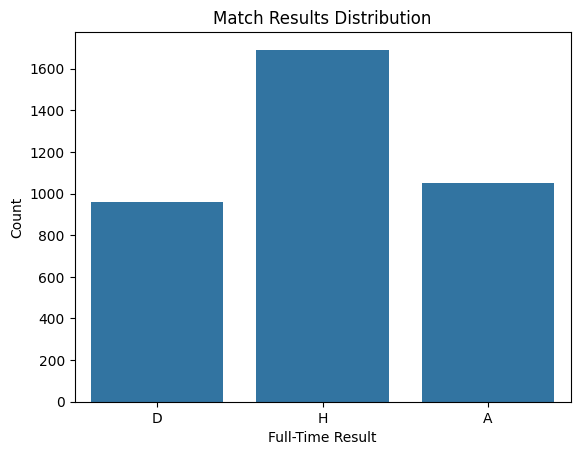

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='FTR', data=df_clean)
plt.title("Match Results Distribution")
plt.xlabel("Full-Time Result")
plt.ylabel("Count")
plt.show()

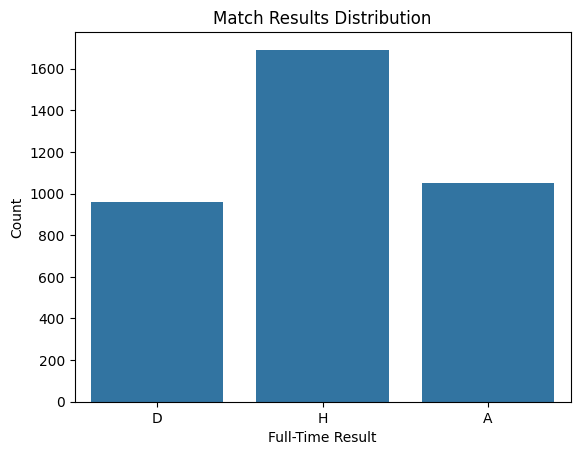

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='FTR', data=df_clean)
plt.title("Match Results Distribution")
plt.xlabel("Full-Time Result")
plt.ylabel("Count")
plt.show()

In [ ]:
#supervised model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df_clean[['HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HY', 'AY']]
y = df_clean['FTR'].map({'H': 1, 'D': 0, 'A': -1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

Accuracy: 0.6108108108108108
              precision    recall  f1-score   support

          -1       0.55      0.62      0.58       196
           0       0.45      0.19      0.26       192
           1       0.67      0.84      0.74       352

    accuracy                           0.61       740
   macro avg       0.56      0.55      0.53       740
weighted avg       0.58      0.61      0.58       740

[[121  23  52]
 [ 62  36  94]
 [ 36  21 295]]


In [ ]:
#Unsupervised model
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

team_stats = df_clean.groupby('HomeTeam').agg({
    'FTHG': 'mean',
    'FTAG': 'mean',
    'HS': 'mean',
    'HST': 'mean',
    'HY': 'mean'
}).reset_index()

team_stats.columns = [
    'Team',
    'AvgHomeGoals',
    'AvgGoalsConceded',
    'AvgShots',
    'AvgShotsOnTarget',
    'AvgYellowCards'
]

features = team_stats[['AvgHomeGoals', 'AvgGoalsConceded', 'AvgShots', 'AvgShotsOnTarget', 'AvgYellowCards']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
team_stats['Cluster'] = kmeans.fit_predict(scaled_features)

team_stats.head()

,Team,AvgHomeGoals,AvgGoalsConceded,AvgShots,AvgShotsOnTarget,AvgYellowCards,Cluster
0,Alaves,1.034014,1.095238,11.299320,3.544218,2.741497,2
1,Almeria,1.342105,1.526316,13.973684,4.973684,2.368421,0
2,Ath Bilbao,1.524324,0.886486,13.567568,4.827027,2.129730,0
3,Ath Madrid,1.956989,0.704301,14.344086,5.333333,2.172043,0
4,Barcelona,2.675676,0.810811,17.383784,6.983784,1.697297,1


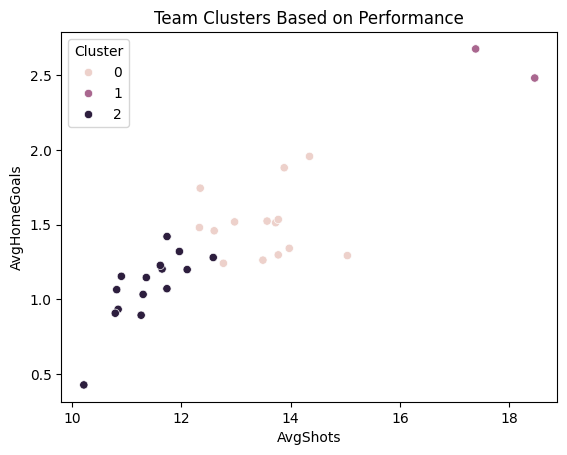

In [ ]:
#Visualization
sns.scatterplot(data=team_stats, x='AvgShots', y='AvgHomeGoals', hue='Cluster')
plt.title("Team Clusters Based on Performance")
plt.show()

In [22]:
df_clean.to_csv("data/cleaned_laliga.csv", index=False)
print("Saved cleaned dataset.")

Saved cleaned dataset.
